# Evaluate Generation on Unseen Protocols.

## Prepare Notebook.

### Import Libraries.

In [16]:
import os
import sys
import yaml

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm


### Constants and Paths.

In [2]:
h5ad_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/LPHO012/projected_LPHO12_all_exp.h5ad"
simulation_data_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-02-20_01-28-16_807188d0"
metadata_csv_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/table_metadata_theis_unmix8.xlsx"
annotation_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/forward/conditional_model/flow_matching/config/annotation/default.yaml"
dump_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-02-20_01-28-16_807188d0/plots"

config_path = os.path.join(simulation_data_dir, "config.yaml")
results_path = os.path.join(simulation_data_dir, "fwd_results.npz")
cond_data_path = os.path.join(simulation_data_dir, "condition_data.pkl")

experiment_id = "LPHO012"

In [22]:
sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import get_shuffled_populations

### Read Data.

### Read Annotation configurations.

In [3]:
with open(annotation_config_path, "r") as fb:
    ann_config = yaml.safe_load(fb)
protocol_cols = ann_config["protocol_columns"]

### Read real measurements.

In [4]:
adata_real = sc.read_h5ad(h5ad_path)
le_ct = LabelEncoder().fit(adata_real.obs["cell_type"])
adata_real

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'Unnamed: 25', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'cell_type', 'annotation_final'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'meta', 'processing_steps'
    obsm: 'X_pca', 'X_umap', 'rep'
    layers: 'positives', 'raw'

### Read metadaata csv.

In [5]:
metadata_df = pd.read_excel(metadata_csv_path)
metadata_df.columns = [c.replace("/", "_") for c in metadata_df.columns]
metadata_df = metadata_df.loc[
    metadata_df["experiment_id"] == "LPHO012",
    protocol_cols + ["experiment_number", "experiment_id"]
]
metadata_df

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,experiment_number,experiment_id
262,10,2.5,750,560.0,0.0,10,0,0,0,0.0,20,14,205,LPHO012
263,10,2.5,375,560.0,0.0,10,0,0,0,0.0,20,14,206,LPHO012
264,10,2.5,75,560.0,0.0,10,0,0,0,0.0,20,14,207,LPHO012
265,10,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14,208,LPHO012
266,0,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14,209,LPHO012
267,0,0.0,0,70.0,0.0,0,100,0,0,0.0,20,14,210,LPHO012


### Read simulated data.

In [6]:
sim_data = np.load(results_path)
sim_data.keys()

KeysView(NpzFile '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/forward/flow_matching/requested_protocols/2026-02-20_01-28-16_807188d0/fwd_results.npz' with keys: X, X_channel, X_scatter, ct_logits, ct_probs)

## Evaluating Predictions.

### Prepare Plot Data.

/tmp/ipykernel_1684751/4191261310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for idx, (exp_number, exp_idx) in enumerate(adata_real.obs.groupby("experiment_number").groups.items()):


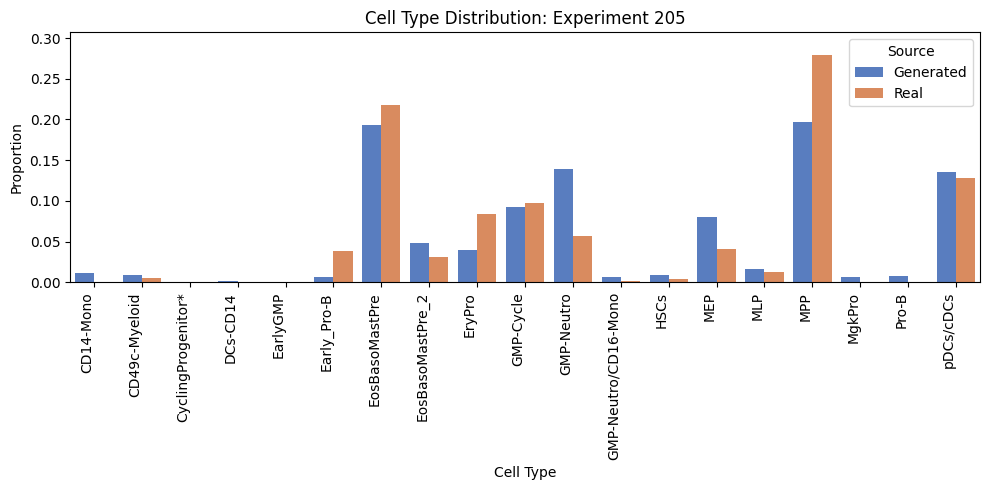

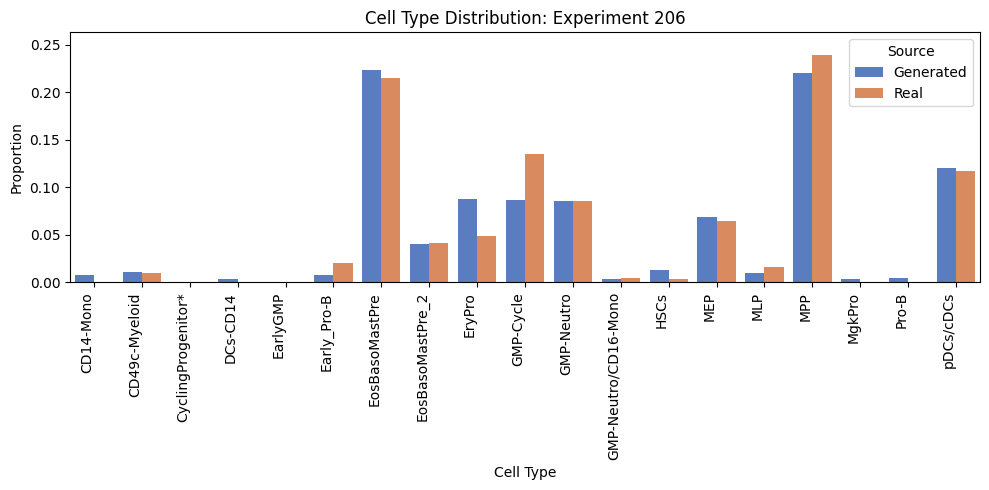

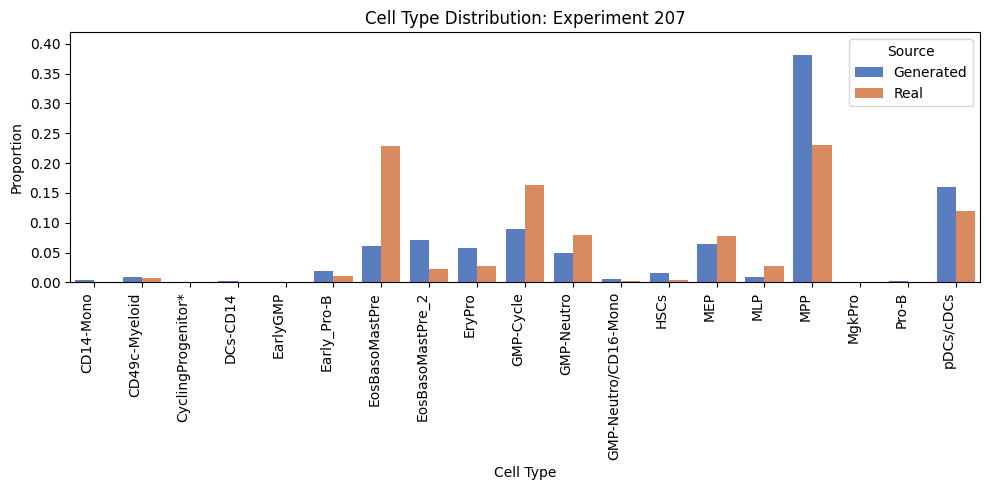

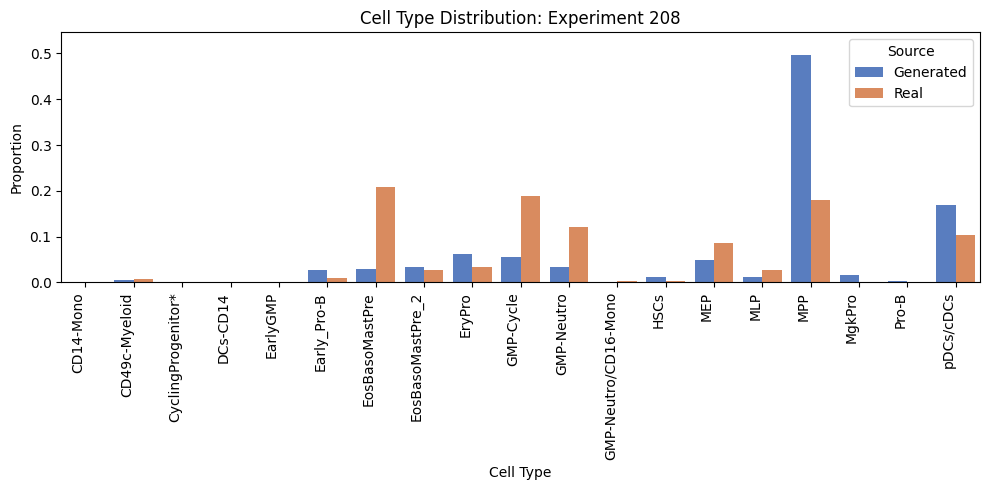

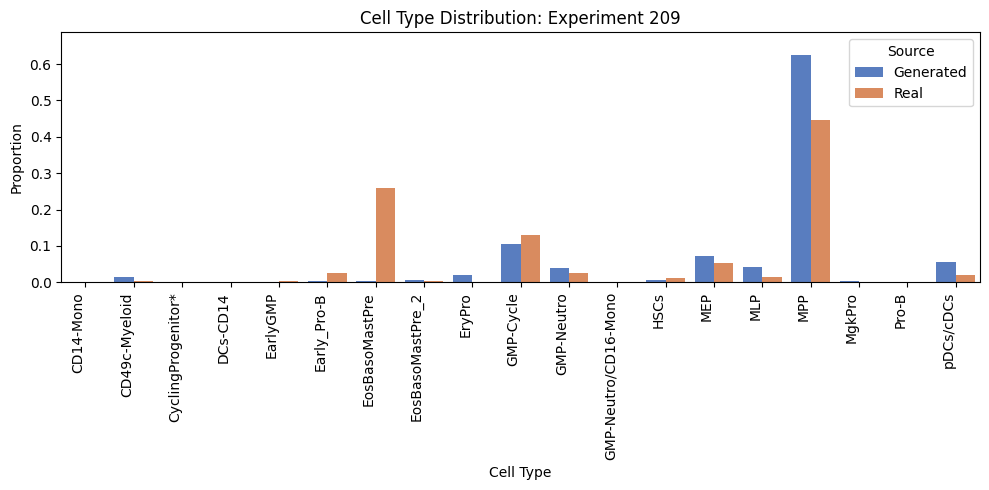

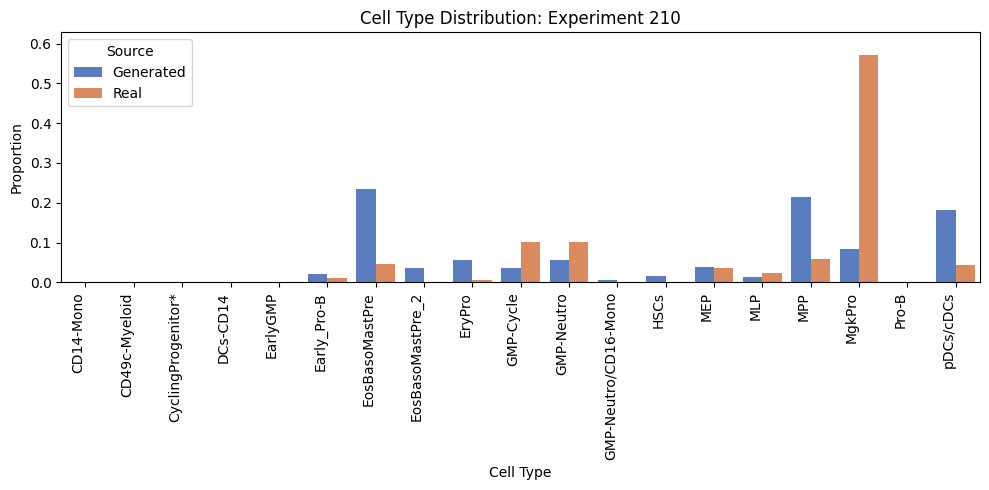

In [10]:
mean_ct_probs = sim_data["ct_probs"].mean(0)
exp_ct_props = {}
for idx, (exp_number, exp_idx) in enumerate(adata_real.obs.groupby("experiment_number").groups.items()):
    pred_ct_probs = mean_ct_probs[idx]
    real_ct_counts = le_ct.transform(adata_real[exp_idx].obs["cell_type"])
    
    real_ct_probs = np.zeros_like(pred_ct_probs)
    for idx in range(len(real_ct_probs)):
        mask = np.argwhere(real_ct_counts == idx)
        real_ct_probs[idx] = len(mask) / len(real_ct_counts)

    exp_ct_props[exp_number] = {
        "pred": pred_ct_probs,
        "real": real_ct_probs,
    }
    
    # 1. Prepare small dataframe for this specific experiment
    df_temp = pd.DataFrame({
        "Cell Type": np.tile(le_ct.classes_, 2),
        "Proportion": np.concatenate([pred_ct_probs, real_ct_probs]),
        "Source": ["Generated"] * len(le_ct.classes_) + ["Real"] * len(le_ct.classes_)
    })

    # 2. Create the figure
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_temp, x="Cell Type", y="Proportion", hue="Source", palette="muted")
    
    # 3. Formatting
    plt.title(f"Cell Type Distribution: Experiment {exp_number}")
    plt.xticks(rotation=90, ha='right')
    plt.ylabel("Proportion")
    plt.ylim(0, max(df_temp["Proportion"]) * 1.1) # Add a little headroom
    plt.tight_layout()
    
    # 4. Display or Save
    plt.savefig(
        os.path.join(dump_dir, f"ct_props_{exp_number}.png"),
        dpi=300
    )

## UQ.

### Prepare populations.

In [23]:
n_pops = 10
n_iters = 100
uq_data_per_cond = {}
ct_probs = sim_data["ct_probs"]
for idx, (exp_number, exp_idx) in tqdm(enumerate(adata_real.obs.groupby("experiment_number").groups.items())):
    pred_ct_probs = ct_probs[:, idx]
    populations = get_shuffled_populations(pred_ct_probs, n_pops=n_pops, n_iters=n_iters)
    uq_data_per_cond[exp_number] = populations

/tmp/ipykernel_1684751/4112932884.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for idx, (exp_number, exp_idx) in tqdm(enumerate(adata_real.obs.groupby("experiment_number").groups.items())):
0it [00:00, ?it/s]

6it [00:00, 40.60it/s]


### Compute Variance of Mean per cell type. 

In [27]:
uq_mean_std_mean = {}
uq_std_std_mean = {}
for exp_number, populations in uq_data_per_cond.items():
    mean_probs = populations.mean(-2)
    std_mean_probs = mean_probs.std(-2)
    shuffled_mean_std_mean_probs = std_mean_probs.mean(0)
    shuffled_std_std_mean_probs = std_mean_probs.std(0)
    uq_mean_std_mean[exp_number] = shuffled_mean_std_mean_probs
    uq_std_std_mean[exp_number] = shuffled_std_std_mean_probs


### Visualize results.

<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1684751/3682995477.py:40: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Mean $\sigma$ across shuffles", fontsize=12)


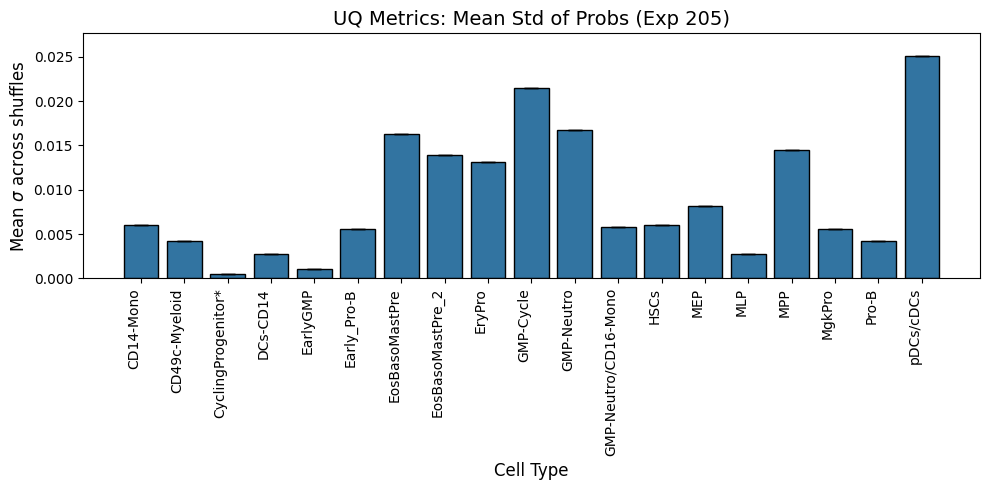

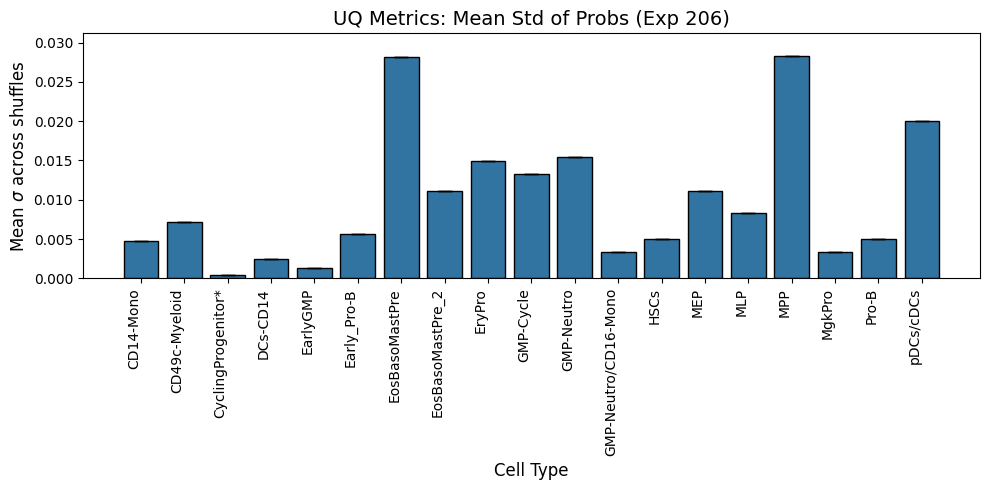

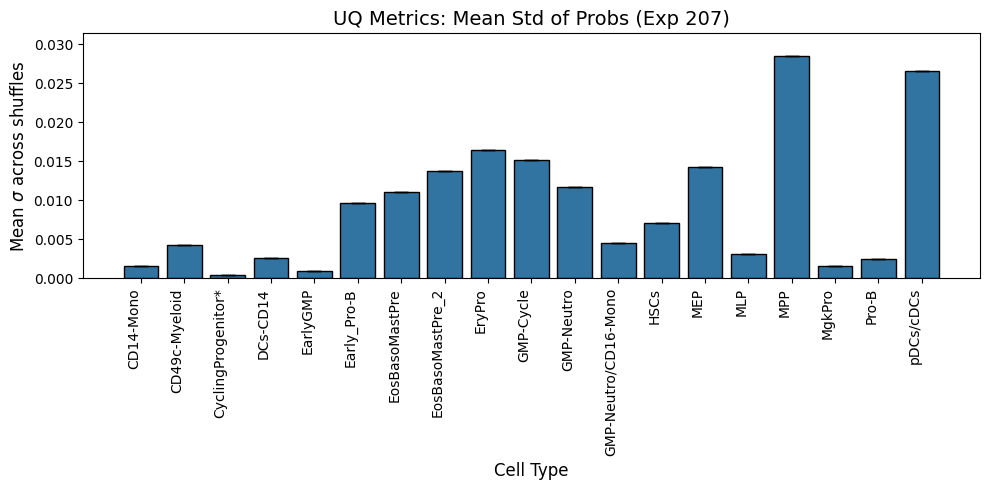

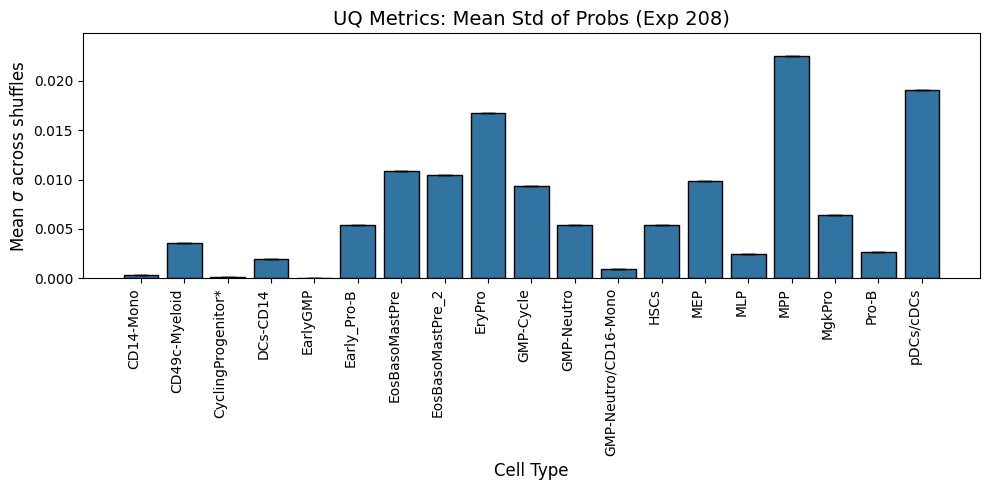

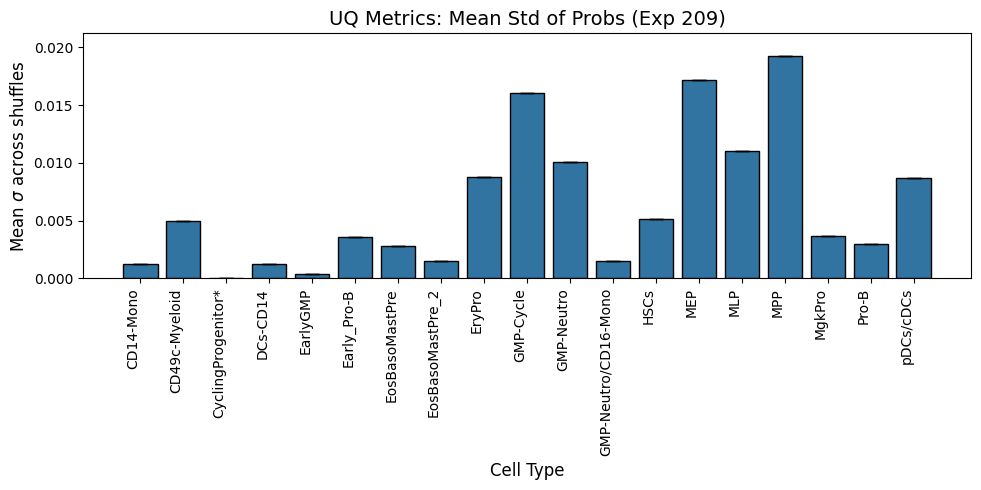

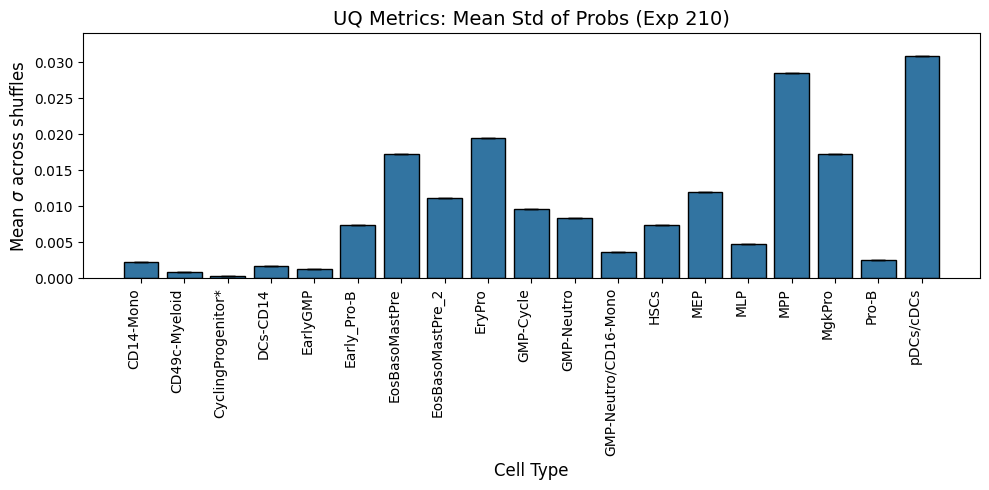

In [35]:
# Assuming uq_data_per_cond and le_ct are defined
cell_type_names = le_ct.classes_

for exp_number, populations in uq_data_per_cond.items():
    # --- Your calculation logic ---
    mean_probs = populations.mean(-2)
    std_mean_probs = mean_probs.std(-2)
    shuffled_mean_std_mean_probs = std_mean_probs.mean(0)
    shuffled_std_std_mean_probs = std_mean_probs.std(0)
    
    uq_mean_std_mean[exp_number] = shuffled_mean_std_mean_probs
    uq_std_std_mean[exp_number] = shuffled_std_std_mean_probs

    # --- PLOTTING PER EXPERIMENT ---
    
    plt.figure(figsize=(10, 5))
    
    # Create the bar plot for the mean uncertainty
    # x: Cell Type names, y: The mean of the standard deviations
    sns.barplot(
        x=cell_type_names, 
        y=shuffled_mean_std_mean_probs,
        # palette="magma",
        edgecolor="black"
    )

    # Add error bars manually using the std_std_mean
    plt.errorbar(
        x=np.arange(len(cell_type_names)), 
        y=shuffled_mean_std_mean_probs, 
        yerr=shuffled_std_std_mean_probs, 
        fmt='none', 
        c='black', 
        capsize=5
    )

    # Formatting
    plt.title(f"UQ Metrics: Mean Std of Probs (Exp {exp_number})", fontsize=14)
    plt.xlabel("Cell Type", fontsize=12)
    plt.ylabel("Mean $\sigma$ across shuffles", fontsize=12)
    plt.xticks(rotation=90, ha='right')
    
    # Optional: adjust y-axis to make room for error bars
    y_max = (shuffled_mean_std_mean_probs + shuffled_std_std_mean_probs).max()
    plt.ylim(0, y_max * 1.1)
    
    plt.tight_layout()
    # 4. Display or Save
    plt.savefig(
        os.path.join(dump_dir, f"ct_props_uq_mean_std_{exp_number}.png"),
        dpi=300
    )
    plt.show()



### Displaying sum of standard deviations.

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1684751/1709283562.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Sum of Mean $\sigma$ across Cell Types")
/tmp/ipykernel_1684751/1709283562.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


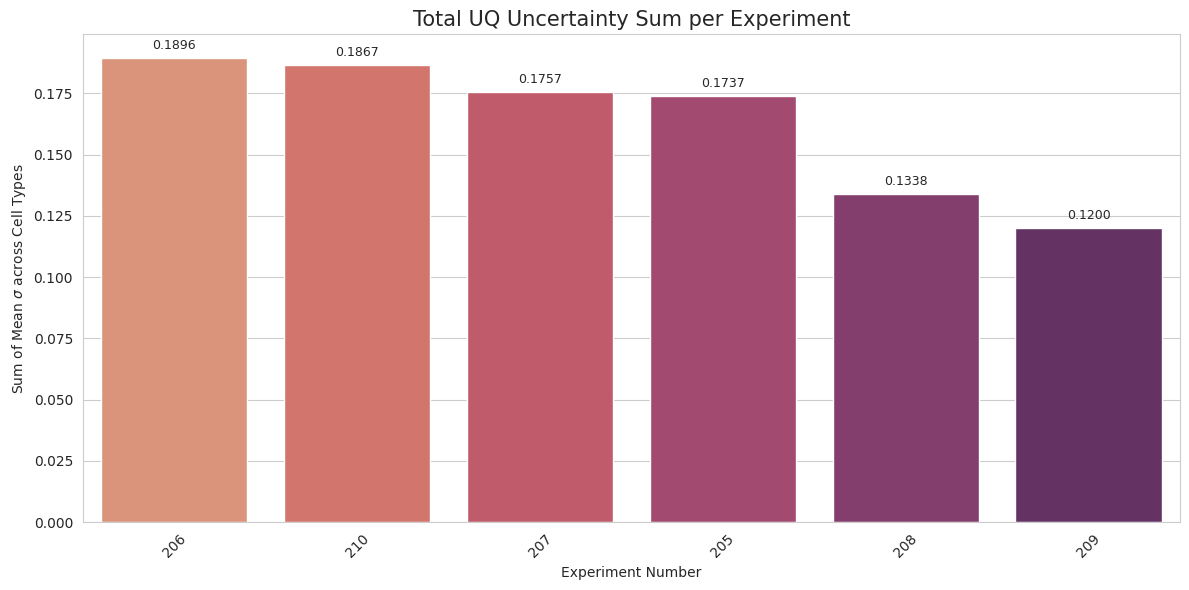

In [42]:
# Assuming uq_data_per_cond and le_ct are defined
cell_type_names = le_ct.classes_

uq_mean_std_mean_sum = {}

for exp_number, populations in uq_data_per_cond.items():
    # --- Your calculation logic ---
    mean_probs = populations.mean(-2)
    std_mean_probs = mean_probs.std(-2)
    shuffled_mean_std_mean_probs = std_mean_probs.mean(0)
    shuffled_std_std_mean_probs = std_mean_probs.std(0)
    
    uq_mean_std_mean_sum[exp_number] = shuffled_mean_std_mean_probs.sum()

#  1. Convert dictionary to DataFrame for Seaborn
summary_df = pd.DataFrame({
    "Experiment": list(uq_mean_std_mean_sum.keys()),
    "Total Uncertainty": list(uq_mean_std_mean_sum.values())
})

# Optional: Sort by uncertainty to see the most/least stable experiments
summary_df = summary_df.sort_values("Total Uncertainty", ascending=False)

# 2. Plotting
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=summary_df, 
    x="Experiment", 
    y="Total Uncertainty", 
    palette="flare"
)

# 3. Aesthetics
plt.title("Total UQ Uncertainty Sum per Experiment", fontsize=15)
plt.ylabel("Sum of Mean $\sigma$ across Cell Types")
plt.xlabel("Experiment Number")
plt.xticks(rotation=45)

# Add value labels on top of bars for precision
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()

# 4. Display or Save
plt.savefig(
    os.path.join(dump_dir, f"ct_props_uq_mean_sum_std.png"),
    dpi=300
)
plt.show()

plt.show()